In [1]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.3 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [44]:
import pandas as pd
Sust_bond_data = pd.read_csv('Global Sustainable Bonds Data.csv')
susBond_DF = pd.DataFrame(Sust_bond_data)

# remove null col
susBond_DF.dropna(axis=1,how='all',inplace=True)
susBond_DF.dropna(axis=1,thresh=1457,inplace=True)
susBond_DF.fillna({'External  Reviewer\n':'missing'},inplace=True)
susBond_DF.fillna({'Latest External Review Report':'missing'},inplace=True)

# trim bn from amnt col and convert to float
susBond_DF[['Amount issued (USD bn.)']] = susBond_DF[['Amount issued (USD bn.)']].map(lambda x: float(x.rstrip('bn')))
susBond_DF[['SectorL1','SectorL2']] = susBond_DF['Issuer sector'].str.split(' - ',n=1, expand=True)

# susBond_DF.info()
# susBond_DF.head()

# count nulls in date cols
susBond_DF.isnull().sum()
# waterfall logic on the date columns to get the true null
# simple stats on number columns (describe)
# visualise paired relationships on a scatterplot matrix
# possible to predict the missing values based on other values? e.g is there a relationship between country and reviewer?
# visualise the data using the various graph types from NB and from Wk 3 esp the types of graphs at the start of the material
# how does supervised ML - classn and LinReg apply. what questions would I ask - need this for features and targets
# same question for unsupervised - cluster analysis
# the two data sets and the combined dataset
# creating a new column to capture the A B delineation
# the 6 ways in which sci-kit learn can be used (slide 27)



Issuer Name                      0
Issuer location                  0
Issuer sector                    0
Bond type                        0
Bonds per type                   0
Amount issued (USD bn.)          0
External  Reviewer\n             0
Latest External Review Report    0
SectorL1                         0
SectorL2                         0
dtype: int64

In [67]:
susBond_DF.info()


<class 'pandas.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Issuer Name                    2546 non-null   str    
 1   Issuer location                2546 non-null   str    
 2   Issuer sector                  2546 non-null   str    
 3   Bond type                      2546 non-null   str    
 4   Bonds per type                 2546 non-null   int64  
 5   Amount issued (USD bn.)        2546 non-null   float64
 6   External  Reviewer
            2546 non-null   str    
 7   Latest External Review Report  2546 non-null   str    
 8   SectorL1                       2546 non-null   str    
 9   SectorL2                       2546 non-null   str    
dtypes: float64(1), int64(1), str(8)
memory usage: 199.0 KB


In [68]:
susBond_DF.describe()
# after visualising and removing some of the outliers, still not getting a good look at the high volume of lower value data 
# decide to split the dataset into 2: A=Bpt of 2 or less AND Amnt of 0.380bn or less and B = everything else

,Bonds per type,Amount issued (USD bn.)
count,2546.000000,2546.000000
mean,6.525923,1.347973
std,104.791526,7.318343
min,0.000000,0.000000
25%,1.000000,0.100000
50%,2.000000,0.380000
75%,3.000000,0.920000
max,4868.000000,258.640000


In [5]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.0-cp313-cp313-macosx

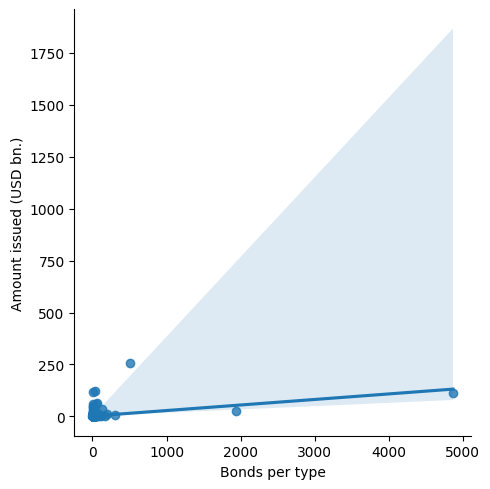

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns

susBond_DF

sns.lmplot(x='Bonds per type',y='Amount issued (USD bn.)',data=susBond_DF)



<Axes: xlabel='Bonds per type', ylabel='Density'>

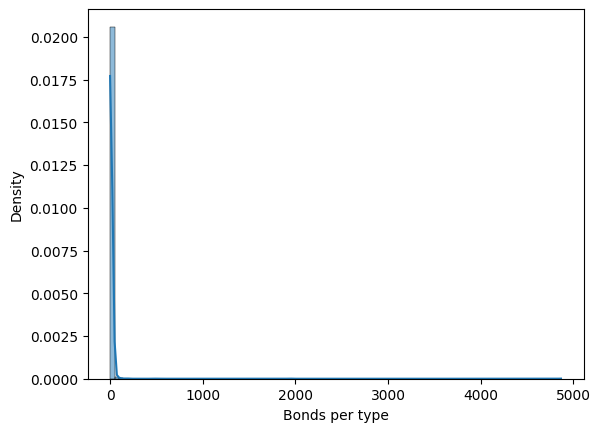

In [7]:
sns.histplot(susBond_DF['Bonds per type'], stat='density',kde=True)

<Axes: xlabel='Amount issued (USD bn.)', ylabel='Density'>

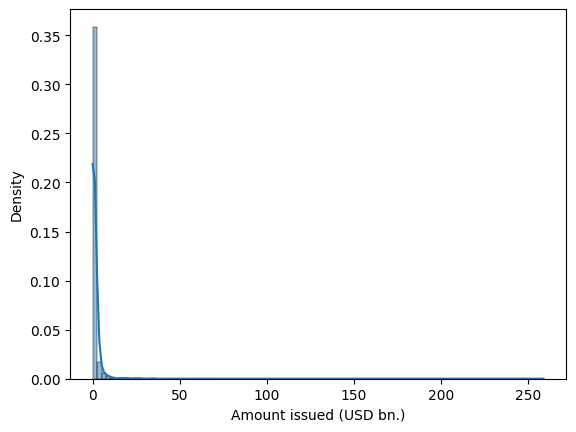

In [8]:
sns.histplot(susBond_DF['Amount issued (USD bn.)'], stat='density',kde=True)

In [9]:
susBond_DF.loc[susBond_DF['Bonds per type']>105]

,Issuer Name,Issuer location,Issuer sector,Bond type,Bonds per type,Amount issued (USD bn.),External Reviewer\n,Latest External Review Report
664,DEUTSCHE BANK AG,Germany,Financials - Banking,Green,128,34.05,ISS-Oekom,Nov-22
808,Fannie Mae (Multi-family green bonds),United States,Financials - Specialty finance,Green,4868,111.26,Cicero,Aug-20
809,Fannie Mae (Multi-family social bonds)\n* Incl...,United States,Financials - Specialty finance,Social,1942,24.95,Sustainalytics,Dec-20
810,Fannie Mae (Single-family green bonds),United States,Financials - Specialty finance,Green,109,2.46,Cicero,Jun-20
871,Freddie Mac (Multi-family social bonds),United States,Financials - Specialty finance,Social,307,5.10,Sustainalytics,Aug-20
873,Freddie Mac (Single-family green bonds),United States,Financials - Specialty finance,Green,173,2.57,Cicero,Nov-21
1177,INTERNATIONAL BANK FOR RECONSTRUCTION AND DEVE...,Supranationals,SSA - Supranationals,Sustainability,507,258.64,missing,missing
1422,LANDESBANK BADEN-WÜRTTEMBERG,Germany,Financials - Banking,Green,198,11.05,ISS-Oekom,Mar-22


In [10]:
susBond_DF.loc[susBond_DF['Amount issued (USD bn.)']>80]

,Issuer Name,Issuer location,Issuer sector,Bond type,Bonds per type,Amount issued (USD bn.),External Reviewer\n,Latest External Review Report
392,CAISSE D'AMORTISSEMENT DE LA DETTE SOCIALE,France,SSA - Agencies,Social,40,123.79,Vigeo Eiris,Sep-20
788,EUROPEAN UNION,Supranationals,SSA - Supranationals,Social,13,116.32,Sustainalytics,Sep-20
808,Fannie Mae (Multi-family green bonds),United States,Financials - Specialty finance,Green,4868,111.26,Cicero,Aug-20
1177,INTERNATIONAL BANK FOR RECONSTRUCTION AND DEVE...,Supranationals,SSA - Supranationals,Sustainability,507,258.64,missing,missing


In [46]:
Bonds_per_type_A=susBond_DF['Bonds per type']<=3
Amount_issued_A=susBond_DF['Amount issued (USD bn.)']<=0.920
Bonds_per_type_B=susBond_DF['Bonds per type']>3
Amount_issued_B=susBond_DF['Amount issued (USD bn.)']>0.920
susBond_DF_A=susBond_DF[Bonds_per_type_A & Amount_issued_A]
susBond_DF_B=susBond_DF[Bonds_per_type_B & Amount_issued_B]
susBond_DF_C=susBond_DF[Bonds_per_type_A & Amount_issued_B]
susBond_DF_D=susBond_DF[Bonds_per_type_B & Amount_issued_A]
frames=[susBond_DF_C,susBond_DF_D]
susBond_DF_E=pd.concat(frames)
susBond_DF_E.info()

# started at the 50% but upped it to 75% since my goal is to get the highest portion of data but with reduced skew
# possible to optimise skew?
# work on concat / join - pandas website


<class 'pandas.DataFrame'>
Index: 541 entries, 3 to 2510
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Issuer Name                    541 non-null    str    
 1   Issuer location                541 non-null    str    
 2   Issuer sector                  541 non-null    str    
 3   Bond type                      541 non-null    str    
 4   Bonds per type                 541 non-null    int64  
 5   Amount issued (USD bn.)        541 non-null    float64
 6   External  Reviewer
            541 non-null    str    
 7   Latest External Review Report  541 non-null    str    
 8   SectorL1                       541 non-null    str    
 9   SectorL2                       541 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 46.5 KB


In [32]:
susBond_DF['Not outlier']=True

for row in susBond_DF:
    bpt='A'
    aiu='A'
    if susBond_DF['Bonds per type']>3:
        bpt='B'
    if susBond_DF['Amount issued (USD bn.)']>0.920:
        aiu='B'
    if bpt=='B' & aiu=='B':
        susBond_DF['Not outlier']=False

susBond_DF.info()


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [12]:
susBond_DF.head(25)

,Issuer Name,Issuer location,Issuer sector,Bond type,Bonds per type,Amount issued (USD bn.),External Reviewer\n,Latest External Review Report
0,360 ENERGY SOLAR SA,Argentina,Corporate - Energy,Green,1,0.02,missing,missing
1,A.P. MOLLER - MAERSK A/S,Denmark,Corporate - Industrials,Green,1,0.57,Cicero,Nov-21
2,A2A S.P.A.,Italy,Corporate - Utilities,Green,5,2.87,Vigeo Eiris,Feb-22
3,A2A S.P.A.,Italy,Corporate - Utilities,Sustainability Linked Bonds,2,1.14,Vigeo Eiris,Feb-22
4,AAREAL BANK AG,Germany,Financials - Consumer Finance,Green,2,1.07,Sustainalytics,Aug-21
5,AARGAUISCHE KANTONALBANK,Switzerland,Financials - Banking,Green,2,0.21,ISS-Oekom,May-21
6,AB ELECTROLUX (PUBL),Sweden,Corporate - Consumer Discretionary,Green,6,0.60,Cicero,Sep-22
7,AB IGNITIS GRUPE,Lithuania,Corporate - Utilities,Green,2,0.69,Cicero,Jun-17
8,ABANCA CORP BANCARIA SA,Spain,Financials - Banking,Green,2,1.09,Sustainalytics,Jul-21
9,ABEILLE VIE,France,Financials - Insurance,Sustainability,1,0.50,Moody's,Aug-22


In [13]:
susBond_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Issuer Name                    2546 non-null   str    
 1   Issuer location                2546 non-null   str    
 2   Issuer sector                  2546 non-null   str    
 3   Bond type                      2546 non-null   str    
 4   Bonds per type                 2546 non-null   int64  
 5   Amount issued (USD bn.)        2546 non-null   float64
 6   External  Reviewer
            2546 non-null   str    
 7   Latest External Review Report  2546 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 159.3 KB


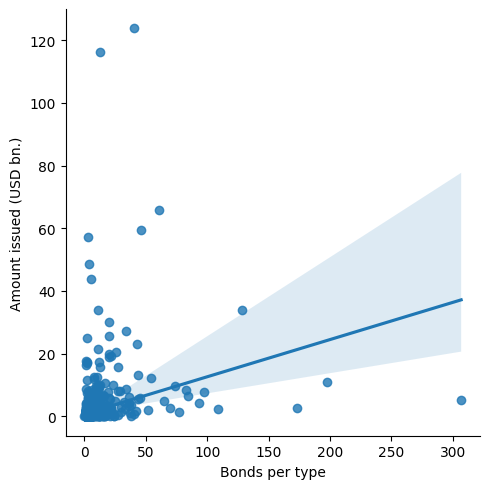

In [14]:

susBond_DF_lessSkew=susBond_DF.drop([808,809,1177], axis=0)

sns.lmplot(x='Bonds per type',y='Amount issued (USD bn.)',data=susBond_DF_lessSkew)


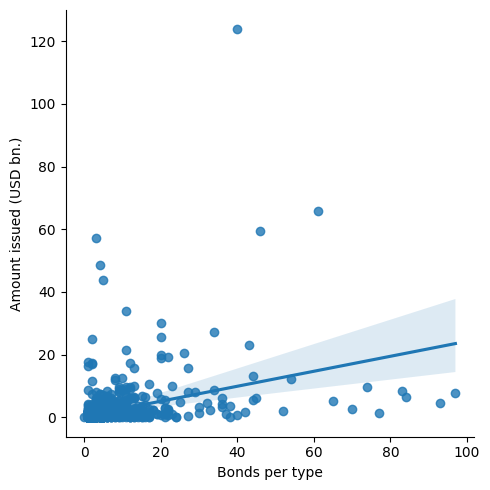

In [15]:
susBond_DF_evenlessSkew=susBond_DF.drop([664,788,808,809,810,871,873,1177,1422], axis=0)
sns.lmplot(x='Bonds per type',y='Amount issued (USD bn.)',data=susBond_DF_evenlessSkew)

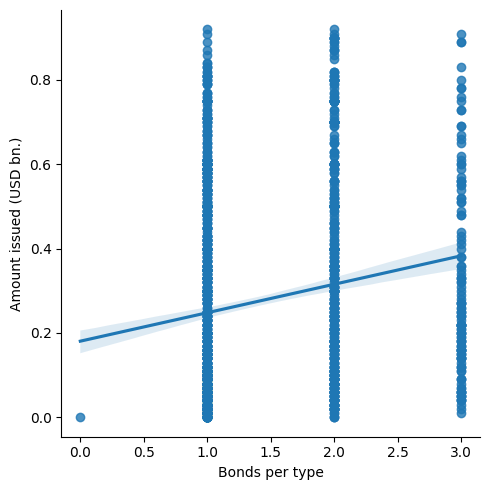

In [16]:
sns.lmplot(x='Bonds per type', y='Amount issued (USD bn.)',data=susBond_DF_A)

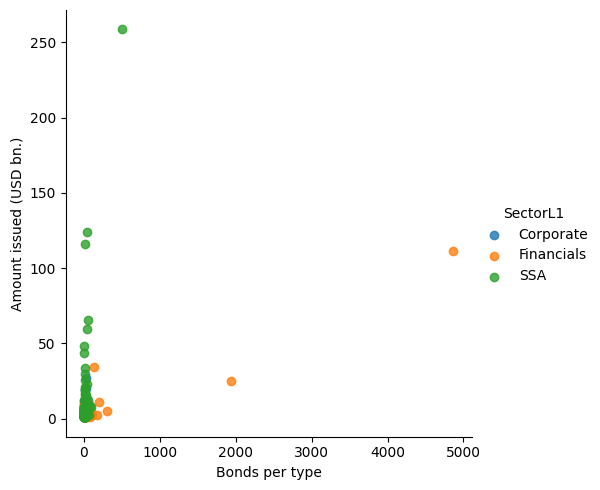

In [73]:
sns.lmplot(x='Bonds per type',y='Amount issued (USD bn.)',data=susBond_DF_B, fit_reg=False, hue='SectorL1')

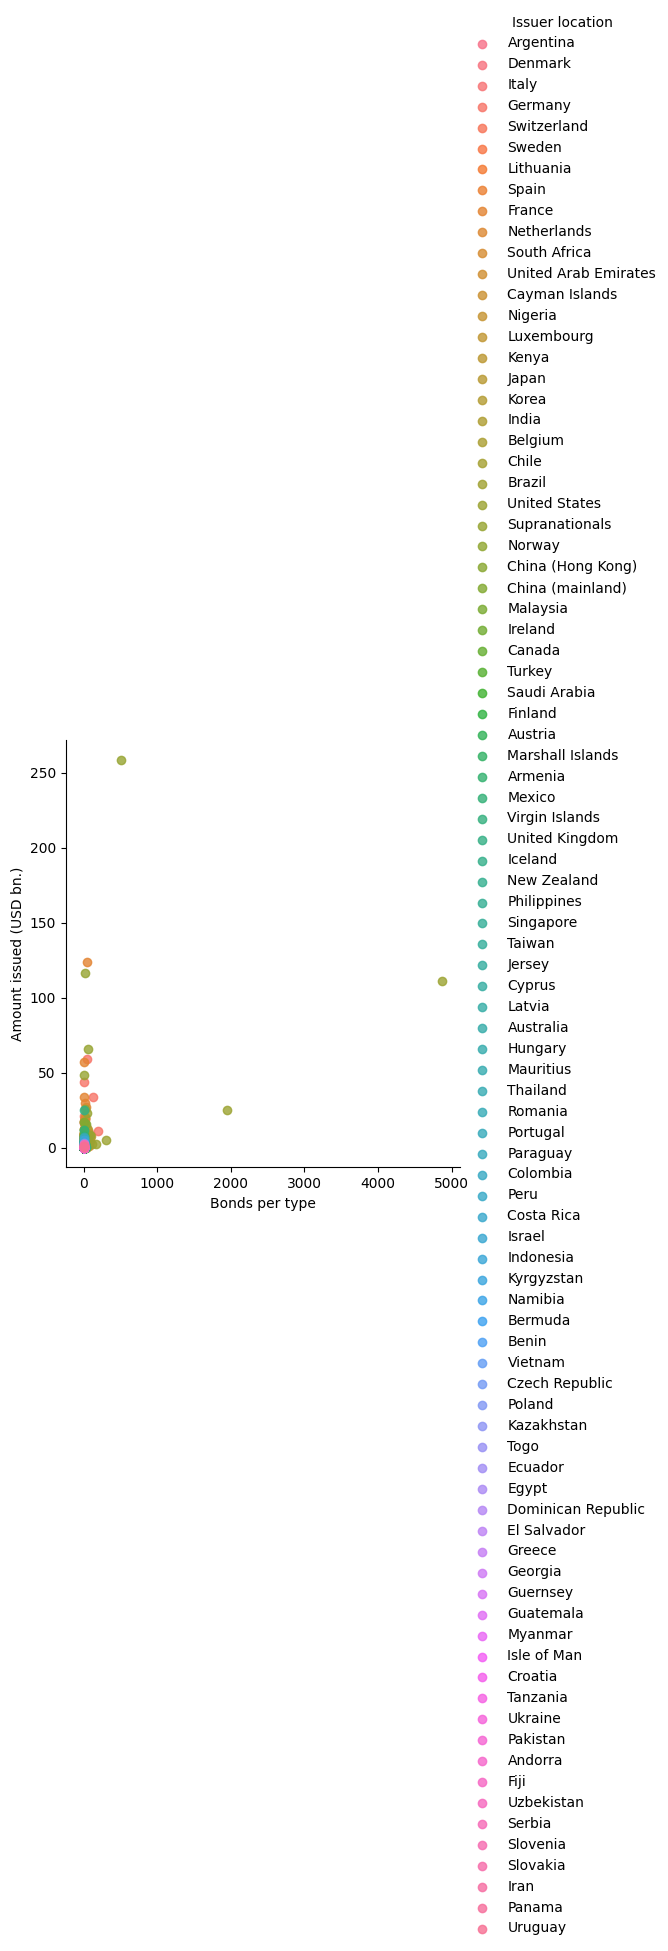

In [18]:
sns.lmplot(x='Bonds per type',y='Amount issued (USD bn.)',data=susBond_DF, fit_reg=False, hue='Issuer location')

Introduce a way of classifying countries - geographic and devlt level
There's a variety and you should look for one that was valid for the time when the data was taken (check kaggle)

<Axes: xlabel='Bonds per type', ylabel='Density'>

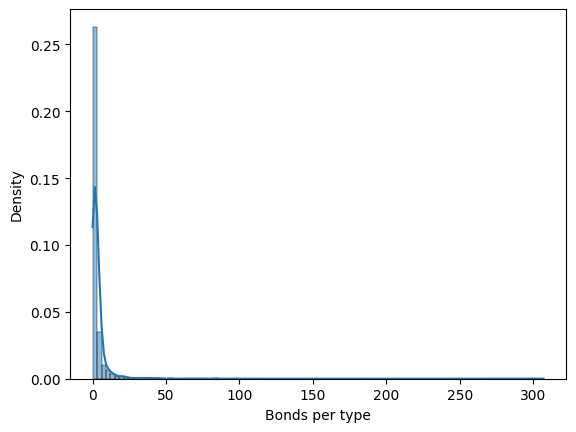

In [19]:
sns.histplot(susBond_DF_lessSkew['Bonds per type'], stat='density',kde=True)


<Axes: xlabel='Amount issued (USD bn.)', ylabel='Density'>

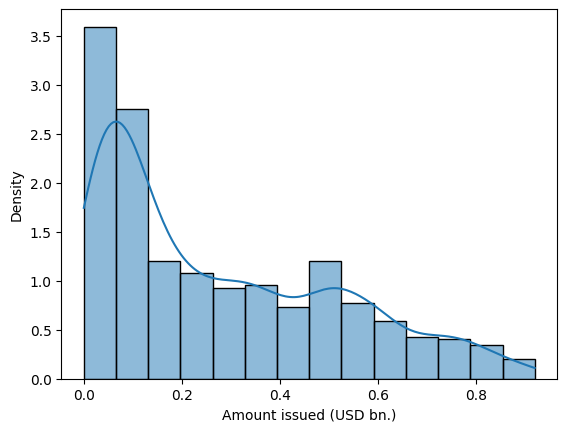

In [55]:
sns.histplot(susBond_DF_A['Amount issued (USD bn.)'], stat='density',kde=True)

<Axes: >

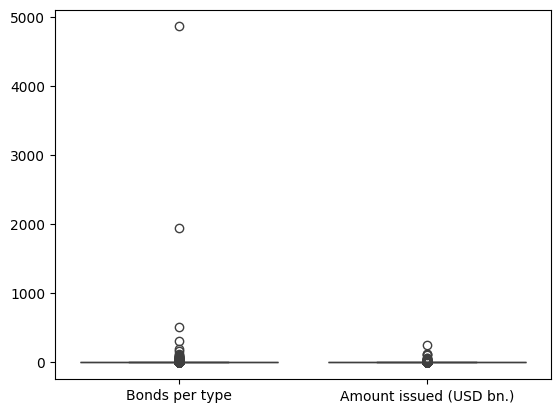

In [21]:
sns.boxplot(data=susBond_DF)

<Axes: >

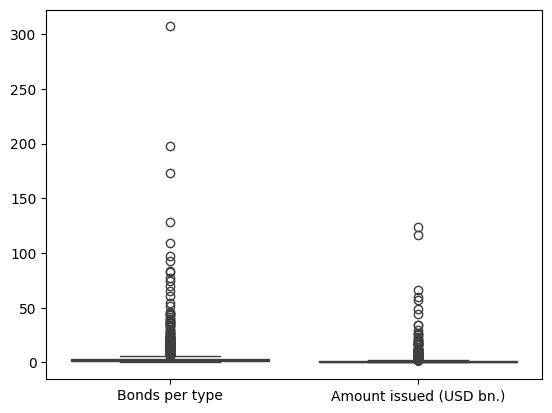

In [22]:
sns.boxplot(data=susBond_DF_lessSkew)

<Axes: >

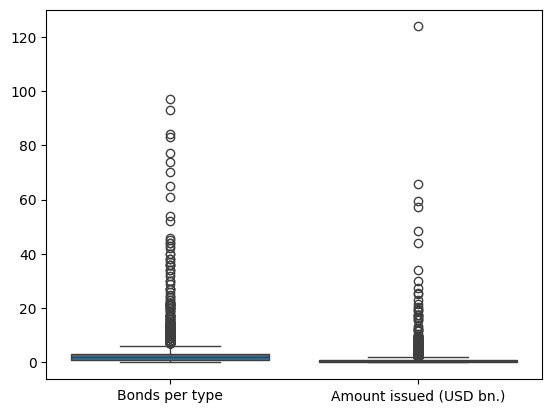

In [23]:
sns.boxplot(data=susBond_DF_evenlessSkew)

<Axes: >

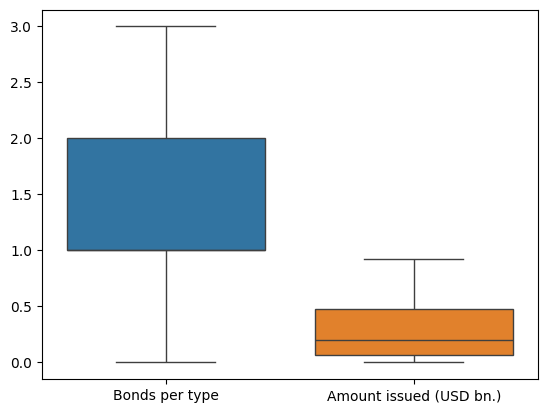

In [24]:
sns.boxplot(data=susBond_DF_A)

<Figure size 640x480 with 0 Axes>

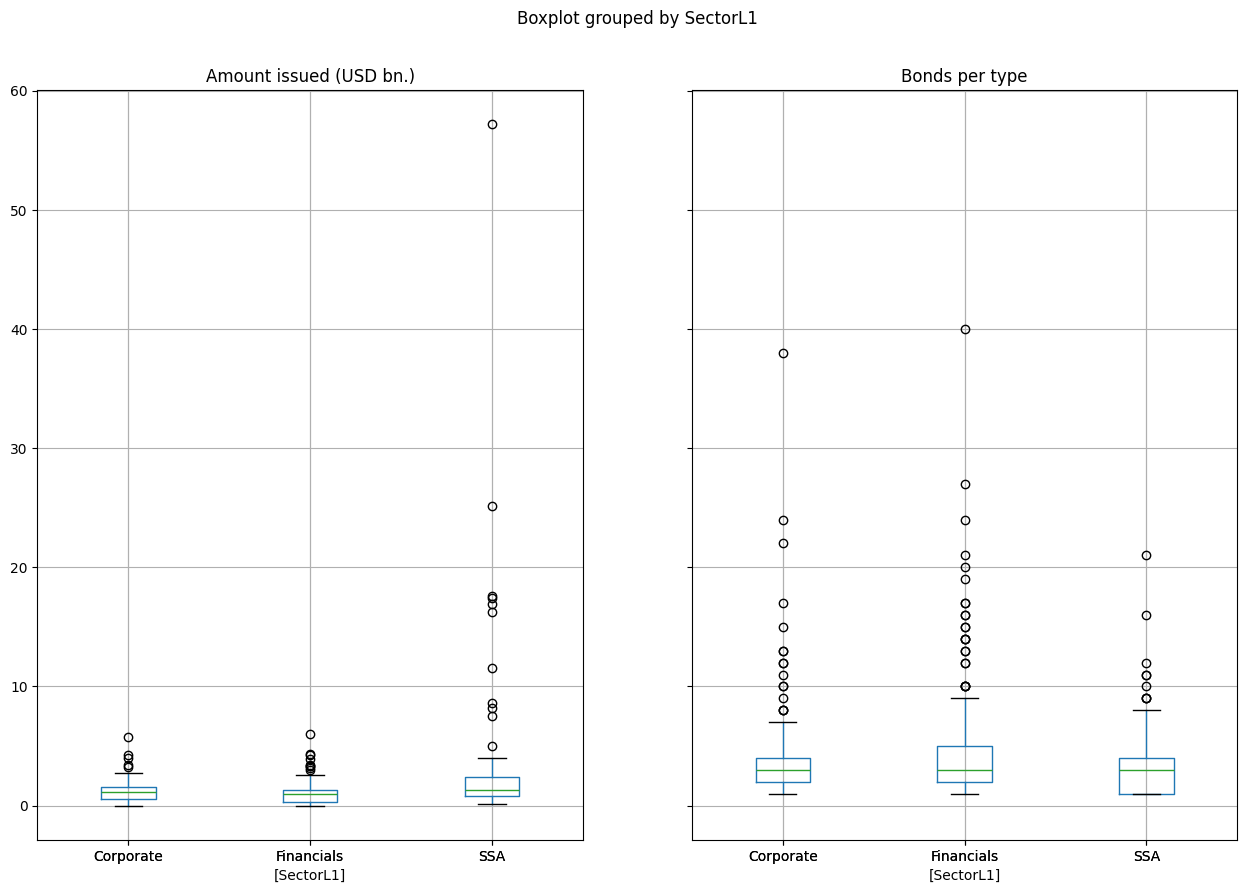

In [57]:
plt.figure()
susBond_DF_E.boxplot(by="SectorL1", figsize=(15, 10))
plt.show()

<Figure size 640x480 with 0 Axes>

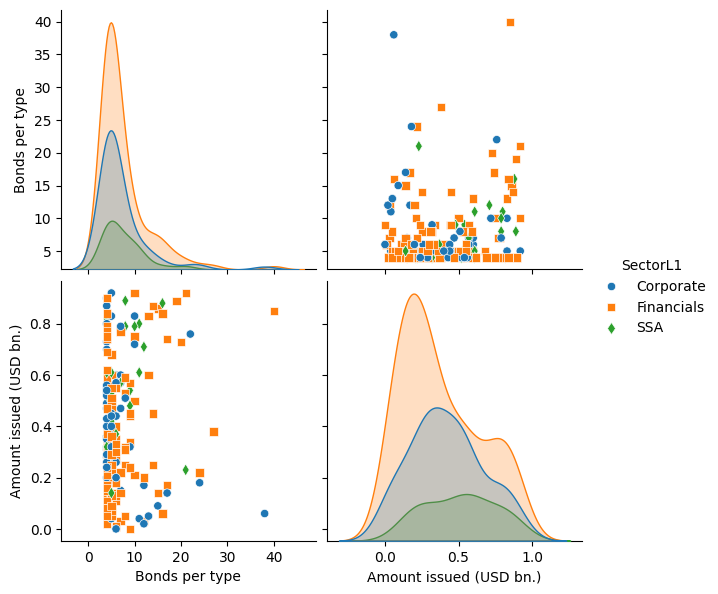

In [65]:
plt.figure()
sns.pairplot(susBond_DF_D, hue='SectorL1', height=3, markers=['o','s','d'])

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W3 Class material-20251214-3/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 40.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Bonds per type', ylabel='Amount issued (USD bn.)'>

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W3 Class material-20251214-3/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 45.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


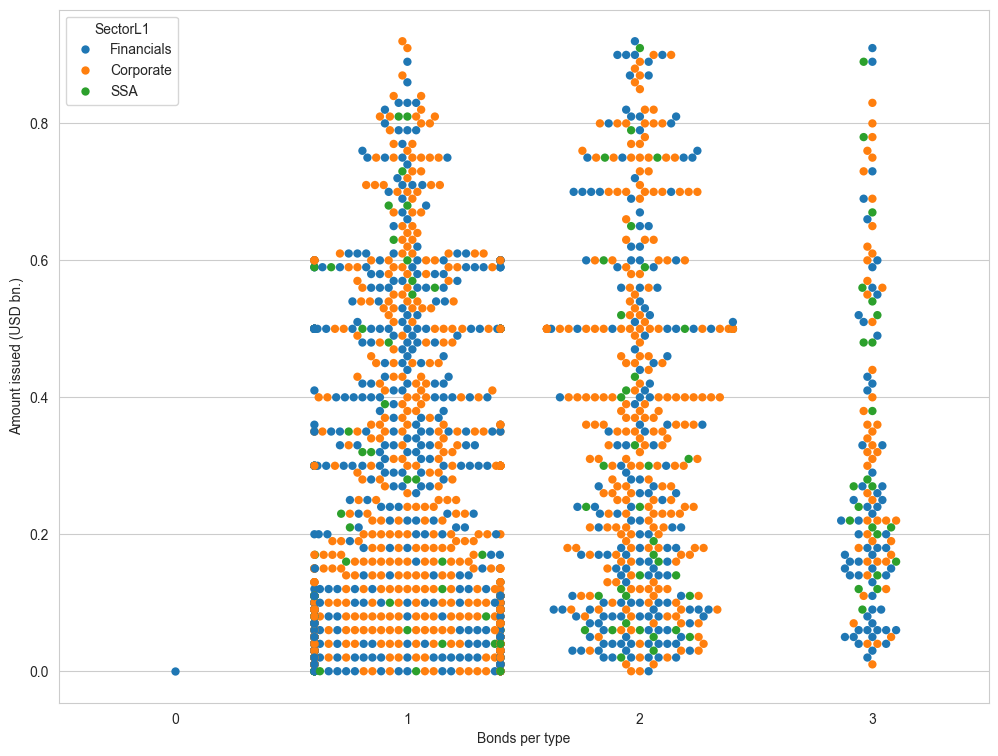

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 9)

sns.swarmplot(x='Bonds per type', y='Amount issued (USD bn.)', data=susBond_DF_A, hue='SectorL1', size=6)

<Axes: xlabel='SectorL1', ylabel='Amount issued (USD bn.)'>

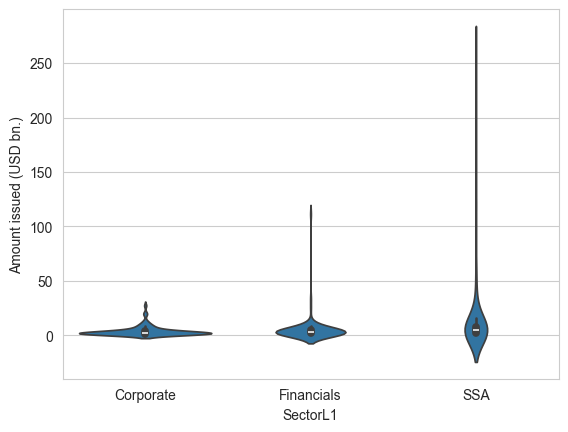

In [79]:
sns.set_style('whitegrid')

sns.violinplot(x='SectorL1', y='Amount issued (USD bn.)', data=susBond_DF_B)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Energy'),
  Text(1, 0, 'Industrials'),
  Text(2, 0, 'Utilities'),
  Text(3, 0, 'Consumer Finance'),
  Text(4, 0, 'Banking'),
  Text(5, 0, 'Consumer Discretionary'),
  Text(6, 0, 'Insurance'),
  Text(7, 0, 'Real estate'),
  Text(8, 0, 'Agencies'),
  Text(9, 0, 'Financial services'),
  Text(10, 0, 'Supranationals'),
  Text(11, 0, 'Quasi-sovereigns'),
  Text(12, 0, 'Consumer Staples'),
  Text(13, 0, 'Materials'),
  Text(14, 0, 'Communications'),
  Text(15, 0, 'Health Care'),
  Text(16, 0, 'Technology'),
  Text(17, 0, 'Specialty finance'),
  Text(18, 0, 'Sovereigns'),
  Text(19, 0, 'Commercial Finance'),
  Text(20, 0, 'Funds & Trusts')])

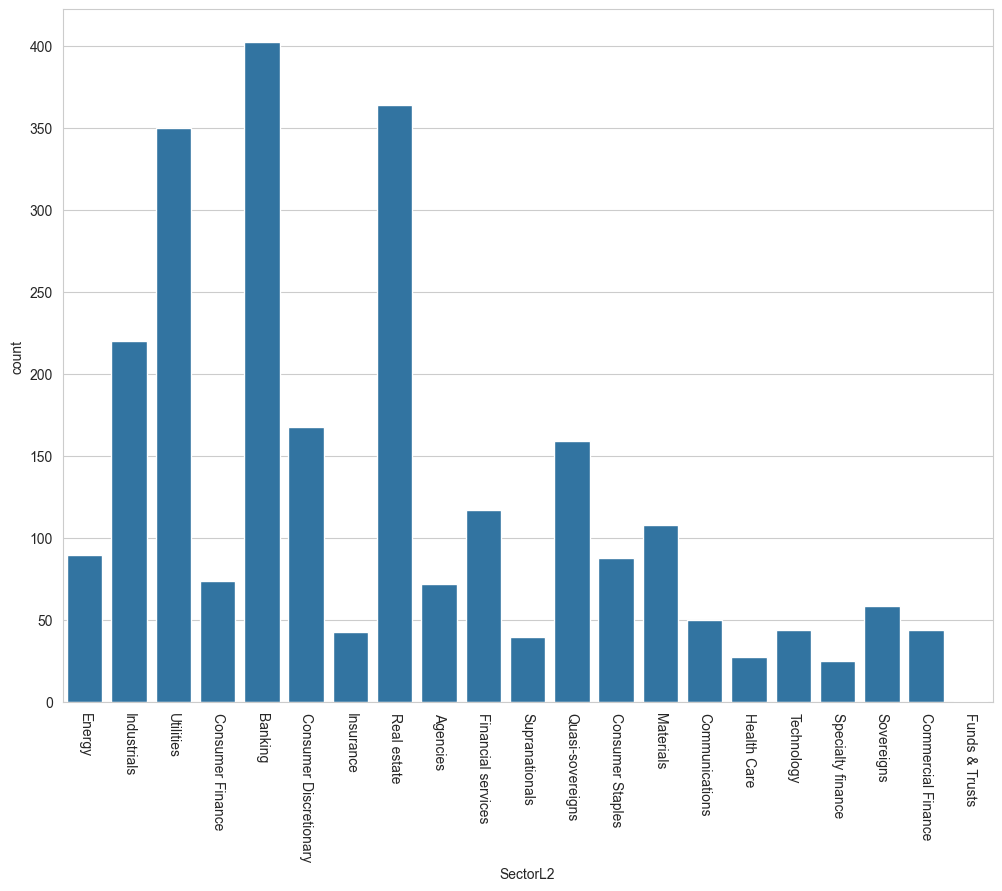

In [83]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 9)

sns.countplot(x='SectorL2',data=susBond_DF)
plt.xticks(rotation=-90)

<Axes: xlabel='Amount issued (USD bn.)', ylabel='Bonds per type'>

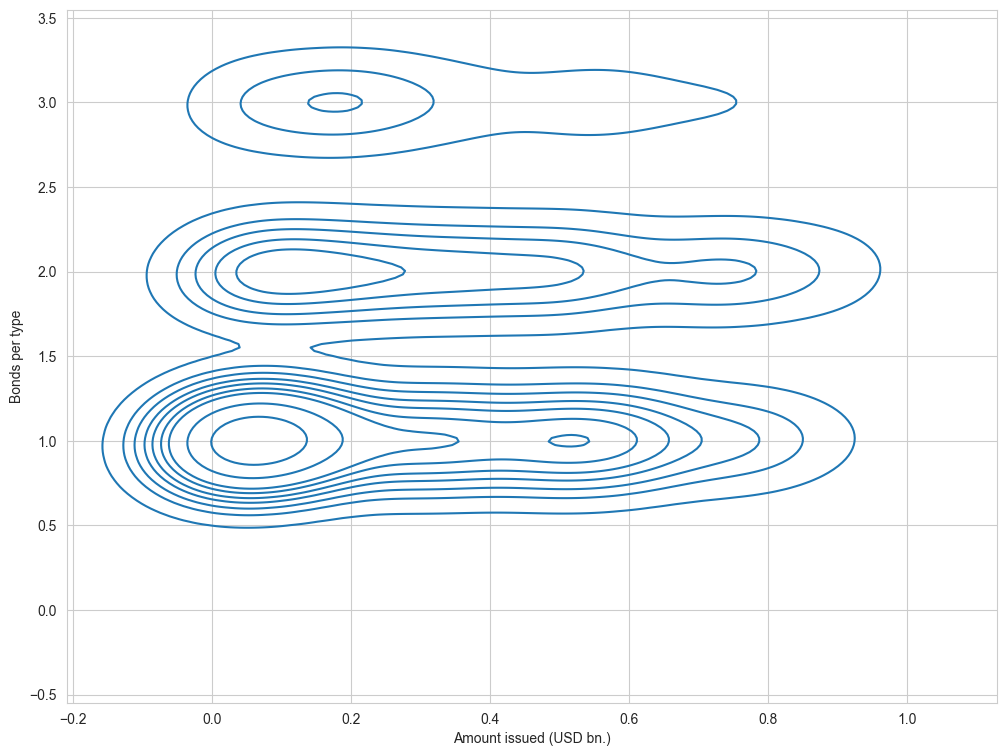

In [86]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 9)

sns.kdeplot(x='Amount issued (USD bn.)',y='Bonds per type',data=susBond_DF_A)


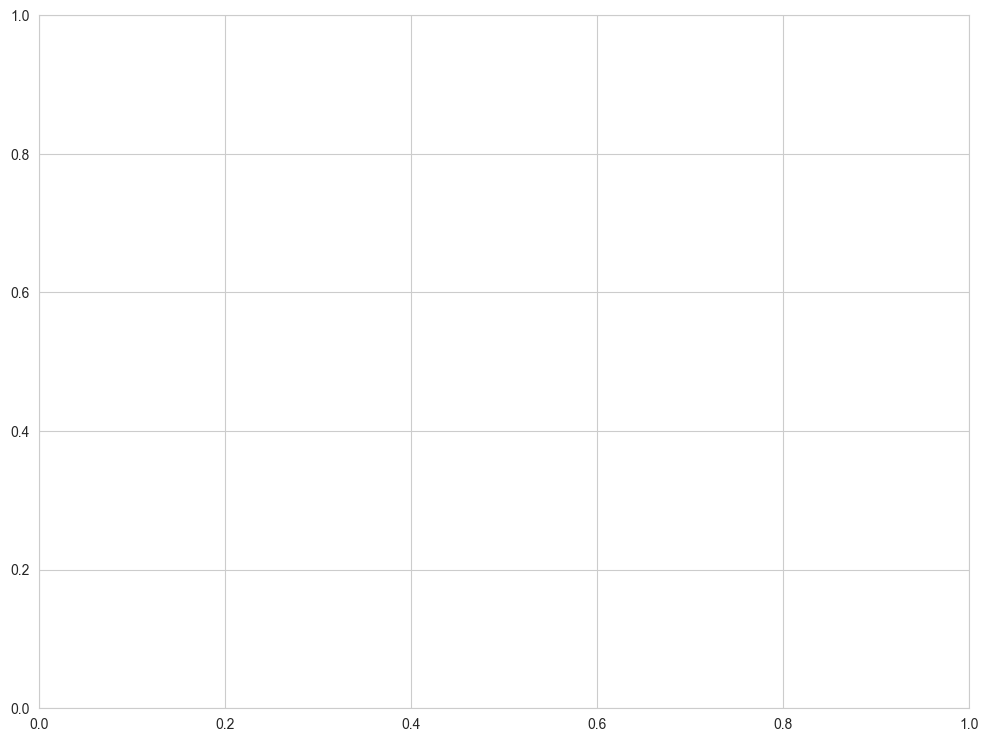

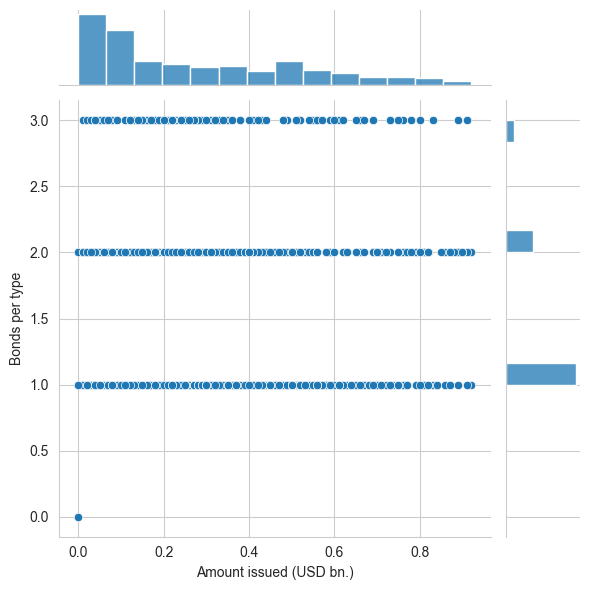

In [87]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 9)

sns.jointplot(x='Amount issued (USD bn.)',y='Bonds per type',data=susBond_DF_A)

In [25]:
pip install -U scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 7.4 MB/s  0:00:02m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [9]:
Green_bond_data = pd.read_csv('Green Bond Data.csv')
grnBond_DF = pd.DataFrame(Green_bond_data)
grnBond_DF.info()
grnBond_DF.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Effective date        2618 non-null   object 
 1   S&P Green Bond Index  2618 non-null   float64
 2   Yield To Maturity     2618 non-null   object 
 3   Yield To Worst        2618 non-null   object 
dtypes: float64(1), object(3)
memory usage: 81.9+ KB


,Effective date,S&P Green Bond Index,Yield To Maturity,Yield To Worst
0,4/30/2013,139.49,2.29%,2.29%
1,05/01/2013,139.29,2.20%,2.20%
2,05/02/2013,138.99,2.17%,2.17%
3,05/03/2013,139.20,2.19%,2.19%
4,05/06/2013,138.81,2.19%,2.19%


In [12]:
Green_bond_index_fund_data = pd.read_csv('iShares Green Bond Index Fund (IE).csv')
grnBndIF_DF = pd.DataFrame(Green_bond_data)
grnBndIF_DF.info()
grnBndIF_DF.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Effective date        2618 non-null   object 
 1   S&P Green Bond Index  2618 non-null   float64
 2   Yield To Maturity     2618 non-null   object 
 3   Yield To Worst        2618 non-null   object 
dtypes: float64(1), object(3)
memory usage: 81.9+ KB


,Effective date,S&P Green Bond Index,Yield To Maturity,Yield To Worst
0,4/30/2013,139.49,2.29%,2.29%
1,05/01/2013,139.29,2.20%,2.20%
2,05/02/2013,138.99,2.17%,2.17%
3,05/03/2013,139.20,2.19%,2.19%
4,05/06/2013,138.81,2.19%,2.19%
